This notebook builds a surrogate model for the macroeconomic impacts of improvements in biological aging.

To run this notebooks, use the `dynviz-dev` virtual environment, which can be build using the `environment.yml` file located in the same directory as this notebook.

# Imports

In [5]:
# imports
import numpy as np
import os
import pandas as pd
import scipy.interpolate as si
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_decision_forests as tfdf
from sklearn.model_selection import train_test_split


# Set up the NN model

In [6]:
# set some hyperparameters
nodes_per_layer = 20 # multiplied by num inputs
activation_function = "relu"
num_epochs = 100
learning_rate = 0.001
# set up early stopping
callback = keras.callbacks.EarlyStopping(
    monitor='loss', patience=5000
    )
# outputs to train on
output_variables = ["avg_diff"]

In [7]:
# Function to select data
def select_data(df, output_variables):
    if "NPV" in output_variables:
        input_variables = [
            "age_effect",
            "initial_effect",
            "final_effect",
            "mort_effect",
            "prod_effect",
            "fert_effect",
            "discount_rate",
        ]
    elif "pop_diffs_2050" in output_variables:
        input_variables = [
            "age_effect",
            "initial_effect",
            "final_effect",
            "mort_effect",
            "fert_effect",
        ]
    elif "avg_diff" in output_variables:
        input_variables = [
            "age_effect",
            "initial_effect",
            "final_effect",
            "mort_effect",
            "prod_effect",
            "fert_effect",
        ]
    else:
        print("No valid output variable selected")
    # Depending on the sample, there may be duplicates because, e.g.,
    # the discount rate doesn't affect the population changes
    df.drop_duplicates(subset=input_variables, inplace=True)
    X = df[input_variables].values
    y = df[output_variables].values
    print("Size of X", X.shape)
    print("Size of y", y.shape)

    return X, y, df[input_variables + output_variables].copy()

In [10]:
# Read in data for training
cur_dir = os.getcwd()
# read in data to train the model
df = pd.read_csv(os.path.join(cur_dir, "augmented_data_with_linear_predictions.csv"))
X, y, df = select_data(df, output_variables)
print("Size of data: ", df.shape)

Size of X (27472, 6)
Size of y (27472, 1)
Size of data:  (27472, 7)


/var/folders/bw/1cvntf9x02b49nfwgy_qnfn00000gp/T/ipykernel_22542/1519663627.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(cur_dir, "augmented_data_with_linear_predictions.csv"))


In [11]:
# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, shuffle=True
)
# Training on full dataset is important as need to span the
# entire parameter space
# X_train = X
# y_train = y

# NOT USED HERE at this point
## Aside; if you want to read in the LinearNDInterpolator model, you can use the following cell:

This would be useful, e.g., if you want to use the surrogate model to generate new data points for each epoch.

In [12]:
interpolant_avg_diff = pickle.load(
    open(
        os.path.join(cur_dir, "interpolant_avg_diff.pkl"), "rb"
    )
)
# using
prediction = interpolant_avg_diff(X_test)
print("Predictions = ", prediction[:5])

Predictions =  [[ 172.35931844]
 [1439.89308163]
 [ 743.9468096 ]
 [3032.72926237]
 [1864.2511019 ]]


# Back to setting up the NN model

In [13]:
# Layer setting
num_input = X.shape[1]
num_hidden_layers = 7
num_hidden = np.zeros(num_hidden_layers)
# Start with more nodes per layer and decrease
for i in range(num_hidden_layers):
    num_hidden[i] = (nodes_per_layer - i * 2) * num_input
# num_hidden = nodes_per_layer * num_input
num_output = y.shape[1]
layers_dim = [num_input, num_hidden, num_output]
print("Dimensions of each layer are {}".format(layers_dim))

Dimensions of each layer are [6, array([120., 108.,  96.,  84.,  72.,  60.,  48.]), 1]


In [ ]:
# Define the neural network
# We use [Keras](https://www.tensorflow.org/guide/keras) to define the
# neural network

# Define the normalization function of the output
def normalize_output(data):
    data_max = np.max(data)
    data_min = np.min(data)
    return (data - data_min) / (data_max - data_min)

# Create a normalization layer for the inputs
# norm_layer = tf.keras.layers.Normalization(input_shape=[num_input,], axis=None)
norm_layer = tf.keras.layers.Normalization(input_shape=[num_input,], axis=-1)


# Adapt the layer to your training data
norm_layer.adapt(X_train)
nn = tf.keras.Sequential(
    [
        norm_layer,
        keras.layers.Dense(num_hidden[0], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_hidden[1], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_hidden[2], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_hidden[3], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_hidden[4], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_hidden[5], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_hidden[6], activation=activation_function, kernel_initializer=initializer),
        keras.layers.Dense(num_output, kernel_initializer=initializer),
    ]
)
print(nn.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 6)                 13        
 on)                                                             
                                                                 
 dense (Dense)               (None, 120)               840       
                                                                 
 dense_1 (Dense)             (None, 108)               13068     
                                                                 
 dense_2 (Dense)             (None, 96)                10464     
                                                                 
 dense_3 (Dense)             (None, 84)                8148      
                                                                 
 dense_4 (Dense)             (None, 72)                6120      
                                                        

/Users/jason.debacker/anaconda3/envs/dynviz-dev/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [15]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=learning_rate)
nn.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['mean_squared_error'])

# Train the model

In [30]:
history = nn.fit(
    X_train, normalize_output(y_train),
    epochs=num_epochs,
    callbacks=[callback],
    # sample_weight=sample_weights,
    batch_size=32,
    validation_data=(X_test,  normalize_output(y_test)),
    validation_freq=5,   # Evaluate every 5 epochs
    verbose=1
    )

Epoch 1/100
  1/687 [..............................] - ETA: 2s - loss: 1.6357e-05 - mean_squared_error: 1.6357e-05

687/687 [==============================] - 1s 1ms/step - loss: 1.2033e-05 - mean_squared_error: 1.2033e-05
Epoch 2/100
687/687 [==============================] - 1s 1ms/step - loss: 1.1751e-05 - mean_squared_error: 1.1751e-05
Epoch 3/100
687/687 [==============================] - 1s 1ms/step - loss: 1.1119e-05 - mean_squared_error: 1.1119e-05
Epoch 4/100
687/687 [==============================] - 1s 1ms/step - loss: 1.2883e-05 - mean_squared_error: 1.2883e-05
Epoch 5/100
687/687 [==============================] - 1s 1ms/step - loss: 1.0585e-05 - mean_squared_error: 1.0585e-05 - val_loss: 1.2557e-04 - val_mean_squared_error: 1.2557e-04
Epoch 6/100
687/687 [==============================] - 1s 1ms/step - loss: 1.1080e-05 - mean_squared_error: 1.1080e-05
Epoch 7/100
687/687 [==============================] - 1s 1ms/step - loss: 1.1797e-05 - mean_squared_error: 1.1797e-05
Epoch 8/100
687/687 [==============================] - 1s 1ms/step - loss: 1.1805e-05 - mean_squared_error: 1.1805e-05


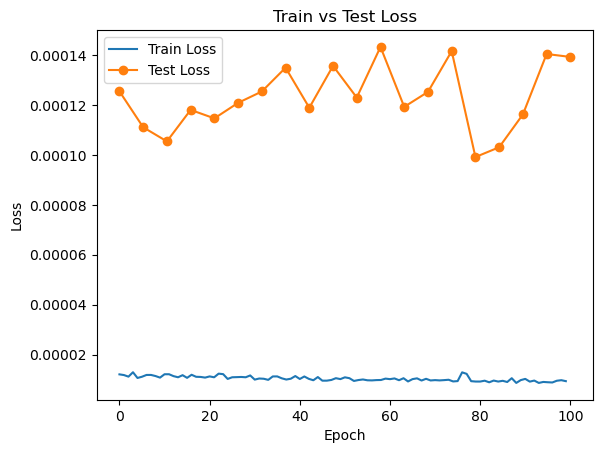

In [31]:
# Plot training and validation loss
plt.plot(np.arange(num_epochs), history.history['loss'], label='Train Loss')
plt.plot(np.linspace(0, num_epochs, num=int(np.ceil(num_epochs/5))), history.history['val_loss'], label='Test Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.legend()
plt.show()

# Check the fit of the model

In [32]:
nn.evaluate(X,  normalize_output(y), verbose=2)


859/859 - 0s - loss: 1.0784e-05 - mean_squared_error: 1.0784e-05 - 446ms/epoch - 519us/step


[1.0783903235278558e-05, 1.0783903235278558e-05]

## Checking against the original data

In [33]:
predictions_normed = nn.predict(X)
# Rescale the predictions
predictions = predictions_normed[:, 0] * (df[output_variables].max().values[0] - df[output_variables].min().values[0]) + df[output_variables].min().values[0]
for i, output_variable in enumerate(output_variables):
            df[output_variable + "_pred"] = predictions#[:, i]
            df[output_variable + "_diff"] = (
                df[output_variable] - df[output_variable + "_pred"]
            )
for var in output_variables:
        print("For {} the mean abs diff is ".format(var), np.absolute(df[var + "_diff"]).mean())
        print("For {} the max abs diff is".format(var), df[var + "_diff"].max())
        print("For {} the min abs diff is".format(var), df[var + "_diff"].min())

859/859 [==============================] - 1s 608us/step
For avg_diff the mean abs diff is  10.901987909441473
For avg_diff the max abs diff is 175.73422396660226
For avg_diff the min abs diff is -450.74700641994104


In [35]:
normalization_layer = nn.get_layer('normalization')
mean = normalization_layer.mean.numpy()
variance = normalization_layer.variance.numpy()
print("Mean: ", mean)
print("Std dev: ", variance**(1/2))

Mean:  [[54.774273   8.310744   8.3668585  1.8895166  1.9011778  0.5317075]]
Std dev:  [[5.94725    4.8036213  4.8182425  1.4179605  1.4143747  0.39473245]]


# Check closeness to runs used in Silver Linings Book

There are a number of runs included in the Silver Linings book that we want to hit **extremely** closely. We can check how close the surrogate model is to these runs.

In [ ]:
# Load model
model = nn#keras.models.load_model("SL_model_full.h5")
output_variables = ["avg_diff"]  # specify the output variable(s) to predict

# read in CSV file with the data to predict
df_book = pd.read_csv("book_runs.csv")
# keep only if discount_rate is 0.02 (value used in book)
df_book = df_book[(df_book["discount_rate"] < 0.03) & (df_book["discount_rate"] > 0.01)]

# Split the X and y variables
if "NPV" in output_variables:
    X_book = df_book[["age_effect", "initial_effect", "final_effect", "mort_effect", "prod_effect", "fert_effect", "discount_rate"]].values
else:
    X_book = df_book[["age_effect", "initial_effect", "final_effect", "mort_effect", "prod_effect", "fert_effect"]].values
y_book = df_book[output_variables].values

# predict using the model
predictions_normed = model.predict(X_book)
predictions = predictions_normed[:, 0] * (df[output_variables].max().values[0] - df[output_variables].min().values[0]) + df[output_variables].min().values[0]
for i, output_variable in enumerate(output_variables):
            df_book[output_variable + "_pred"] = predictions
            df_book[output_variable + "_diff"] = (
                df_book[output_variable] - df_book[output_variable + "_pred"]
            )
for var in output_variables:
        print("For {} the mean abs diff is ".format(var), np.absolute(df_book[var + "_diff"]).mean())
        print("For {} the max abs diff is".format(var), df_book[var + "_diff"].max())
        print("For {} the min abs diff is".format(var), df_book[var + "_diff"].min())


1/1 [==============================] - 0s 15ms/step
For avg_diff the mean abs diff is  15.764213178390209
For avg_diff the max abs diff is 87.2946613499862
For avg_diff the min abs diff is -20.199878574751352
